---
## 🎁 가산점

### A. 데이터의 다양성
- cell 5~8
- **15개 데이터셋 진단 스캔:** `dataset` 디렉토리에 존재하는 모든 화학 데이터셋(15개)을 실시간으로 고속 스캔하여 전체 행 수, 컬럼 프로필, SMILES 구조 내장 여부 등을 요약 테이블로 분석한다.
- **데이터셋 선별:** 스캔 결과를 바탕으로 사용 가능한 고유 샘플 수 등을 고려하여 최종 모델링용 데이터셋으로 `cancer.xlsx`(발암성 데이터셋)를 선정한다.
- **PubChem REST API Fallback 시스템 내장:** SMILES 구조가 부재한 화합물이 입력되거나 결측치가 존재할 때, PubChem REST API를 호출하여 화학물질명 기반으로 Canonical SMILES를 온라인에서 실시간으로 추적하는 Fallback 시스템을 구현한다.

### B. Feature(descriptor)의 다양성
- cell 18~21
- **물리화학적 Descriptor 및 6대 분자 지문 (Fingerprints) 추출:** RDKit 기본 2D Molecular Descriptor(200여 개)뿐만 아니라, RDKit의 대표적인 6대 분자 지문(Morgan, Path-based, MACCS, Atom Pairs, Topological Torsion, Pattern)을 전량 추출하여 가로로 병합한다.
- **접두사(Prefix) 피처 명명법:** 결합된 피처 컬럼의 출처를 쉽게 구분할 수 있도록 각각 `Morgan_`, `RDKit_`, `MACCS_`, `AtomPair_`, `Torsion_`, `Pattern_` 접두사를 동적으로 부여하여 특징 행렬을 구축한다.
- **Joblib 멀티프로세싱 CPU 병렬 가속:** 디스크립터 및 분자 지문 계산 과정에 `joblib` 기반의 멀티코어 병렬 연산(`n_jobs=-1`)을 적용하여 대용량 화학 데이터의 피처 추출 시간을 획득한다.


# 기말고사 Template 1 — Data Pipeline (발암성 QSAR 데이터 정화 및 피처 추출 엔진)

**이름:** 김나연 &nbsp; **학번:** 20250786 &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |


In [6]:
#!pip install pandas numpy matplotlib seaborn openpyxl requests rdkit scikit-learn joblib

In [ ]:
import os
import glob
import openpyxl
import requests
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, AllChem, MACCSkeys
from rdkit.Chem.SaltRemover import SaltRemover
from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import seaborn as sns
import platform

# Matplotlib 글꼴 누락 경고 및 불필요한 FutureWarning 억제
warnings.filterwarnings("ignore", category=UserWarning, message=".*Glyph.*")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
RDLogger.DisableLog('rdApp.*')

## A. 데이터의 다양성

### 1. 15개 화학 데이터셋 실시간 고속 스캔 및 다각적 시각화 (EDA)
- `dataset` 폴더 내에 존재하는 15개 전체 엑셀 데이터셋을 실시간으로 고속 진단(Diagnostic Scan)한다.
- 각 파일의 전체 행 수, 컬럼 수, SMILES 구조식 내장 여부, Mixture 유무, 라벨 컬럼 정보를 요약 표로 출력하고 비교 그래프로 시각화한다.


In [8]:
# =========================================================================
# 'dataset/' 폴더 내 전체 화학 데이터셋 고속 정밀 스캔 (사용 가능 샘플 수 측정)
# =========================================================================
files = glob.glob('dataset/*.xlsx')
scan_results = []

print(f"'dataset/' 폴더 내 총 {len(files)}개의 엑셀 파일 진단 스캔을 고속으로 수행합니다.")

for f in files:
    bn = os.path.basename(f)
    try:
        # 1. 시트명 탐색 및 행 수 구하기
        wb = openpyxl.load_workbook(f, read_only=True)
        sheets = wb.sheetnames
        t_sheet = next((s for s in ['Table S1', 'A. DIRIL (317)', 'version 2', 'Data_invivo', 'Data', 'Data_invitro'] if s in sheets), sheets[0])
        sheet_obj = wb[t_sheet]
        max_r = sheet_obj.max_row
        if max_r is None:
            max_r = sum(1 for _ in sheet_obj.iter_rows(values_only=True))
        wb.close()
        
        # 2. 컬럼명 분석을 위해 헤더 로드
        h_val = 1 if 'Drug Induced Liver Injury' in bn else 0
        df_cols = pd.read_excel(f, sheet_name=t_sheet, header=h_val, nrows=1)
        
        smi_col = next((c for c in df_cols.columns if c.lower() in ['smiles', 'smi', 'smile']), None)
        mix_col = next((c for c in df_cols.columns if c.lower() == 'mixture'), None)
        
        cols_to_use = []
        if smi_col:
            cols_to_use.append(smi_col)
        if mix_col:
            cols_to_use.append(mix_col)
            
        total_rows = max_r - (1 if h_val > 0 else 0)
        
        # SMILES가 없는 경우 사용 가능 행 수 0
        if not smi_col:
            usable_count = 0
            note = 'SMILES 부재'
        else: 
            # 3. 고속 행 개수 카운트 (대형 파일은 5,000행 기반 통계적 비율 추정)
            if total_rows <= 15000:
                df = pd.read_excel(f, sheet_name=t_sheet, header=h_val, usecols=cols_to_use)
                valid_df = df.dropna(subset=[smi_col]).copy()
                valid_df = valid_df[valid_df[smi_col].astype(str).str.strip() != ""]
                if mix_col:
                    usable_df = valid_df[valid_df[mix_col].astype(str).str.strip().str.lower() == 'chemical']
                    usable_count = len(usable_df)
                else:
                    usable_count = len(valid_df)
                note = '전수 카운트 완료'
            else:
                df_sample = pd.read_excel(f, sheet_name=t_sheet, header=h_val, usecols=cols_to_use, nrows=5000)
                valid_sample = df_sample.dropna(subset=[smi_col]).copy()
                valid_sample = valid_sample[valid_sample[smi_col].astype(str).str.strip() != ""]
                if mix_col:
                    usable_sample = valid_sample[valid_sample[mix_col].astype(str).str.strip().str.lower() == 'chemical']
                    ratio = len(usable_sample) / len(df_sample)
                else:
                    ratio = len(valid_sample) / len(df_sample)
                usable_count = int(total_rows * ratio)
                note = f'대형 파일 5,000행 기반 통계적 비율 추정 (비율 {ratio*100:.1f}%)'
        
        scan_results.append({
            '파일명': bn,
            '데이터시트': t_sheet,
            '전체행수': total_rows,
            '열수': len(df_cols.columns),
            'SMILES내장': smi_col is not None,
            'Mixture내장': mix_col is not None,
            '실제사용가능행수': usable_count,
            '비고': note
        })
    except Exception as e:
        scan_results.append({'파일명': bn, '에러': str(e)})

df_scan = pd.DataFrame(scan_results)
display(df_scan)

'dataset/' 폴더 내 총 15개의 엑셀 파일 진단 스캔을 고속으로 수행합니다.


,파일명,데이터시트,전체행수,열수,SMILES내장,Mixture내장,실제사용가능행수,비고
0,acute_inhalation.xlsx,Data,5506,23,True,True,3055,전수 카운트 완료
1,adme_parameters.xlsx,Data,3822,17,True,False,3807,전수 카운트 완료
2,skin_sensitization.xlsx,Data_invivo,13946,25,True,True,10363,전수 카운트 완료
3,acute_dermal.xlsx,Data,2693,22,True,True,0,전수 카운트 완료
4,Exposure_Predictions.xlsx,Data,479585,13,False,False,0,SMILES 부재
5,dart.xlsx,Data,138327,25,True,False,125324,"대형 파일 5,000행 기반 통계적 비율 추정 (비율 90.6%)"
6,ChemicalQC.xlsx,ICE Chemical QC,12780,13,False,False,0,SMILES 부재
7,cHTSMT_ALL.xlsx,Overview,15,1,False,False,0,SMILES 부재
8,functional_use.xlsx,Data,264848,16,True,False,251287,"대형 파일 5,000행 기반 통계적 비율 추정 (비율 94.9%)"
9,cancer.xlsx,Data,10352,28,True,True,9537,전수 카운트 완료


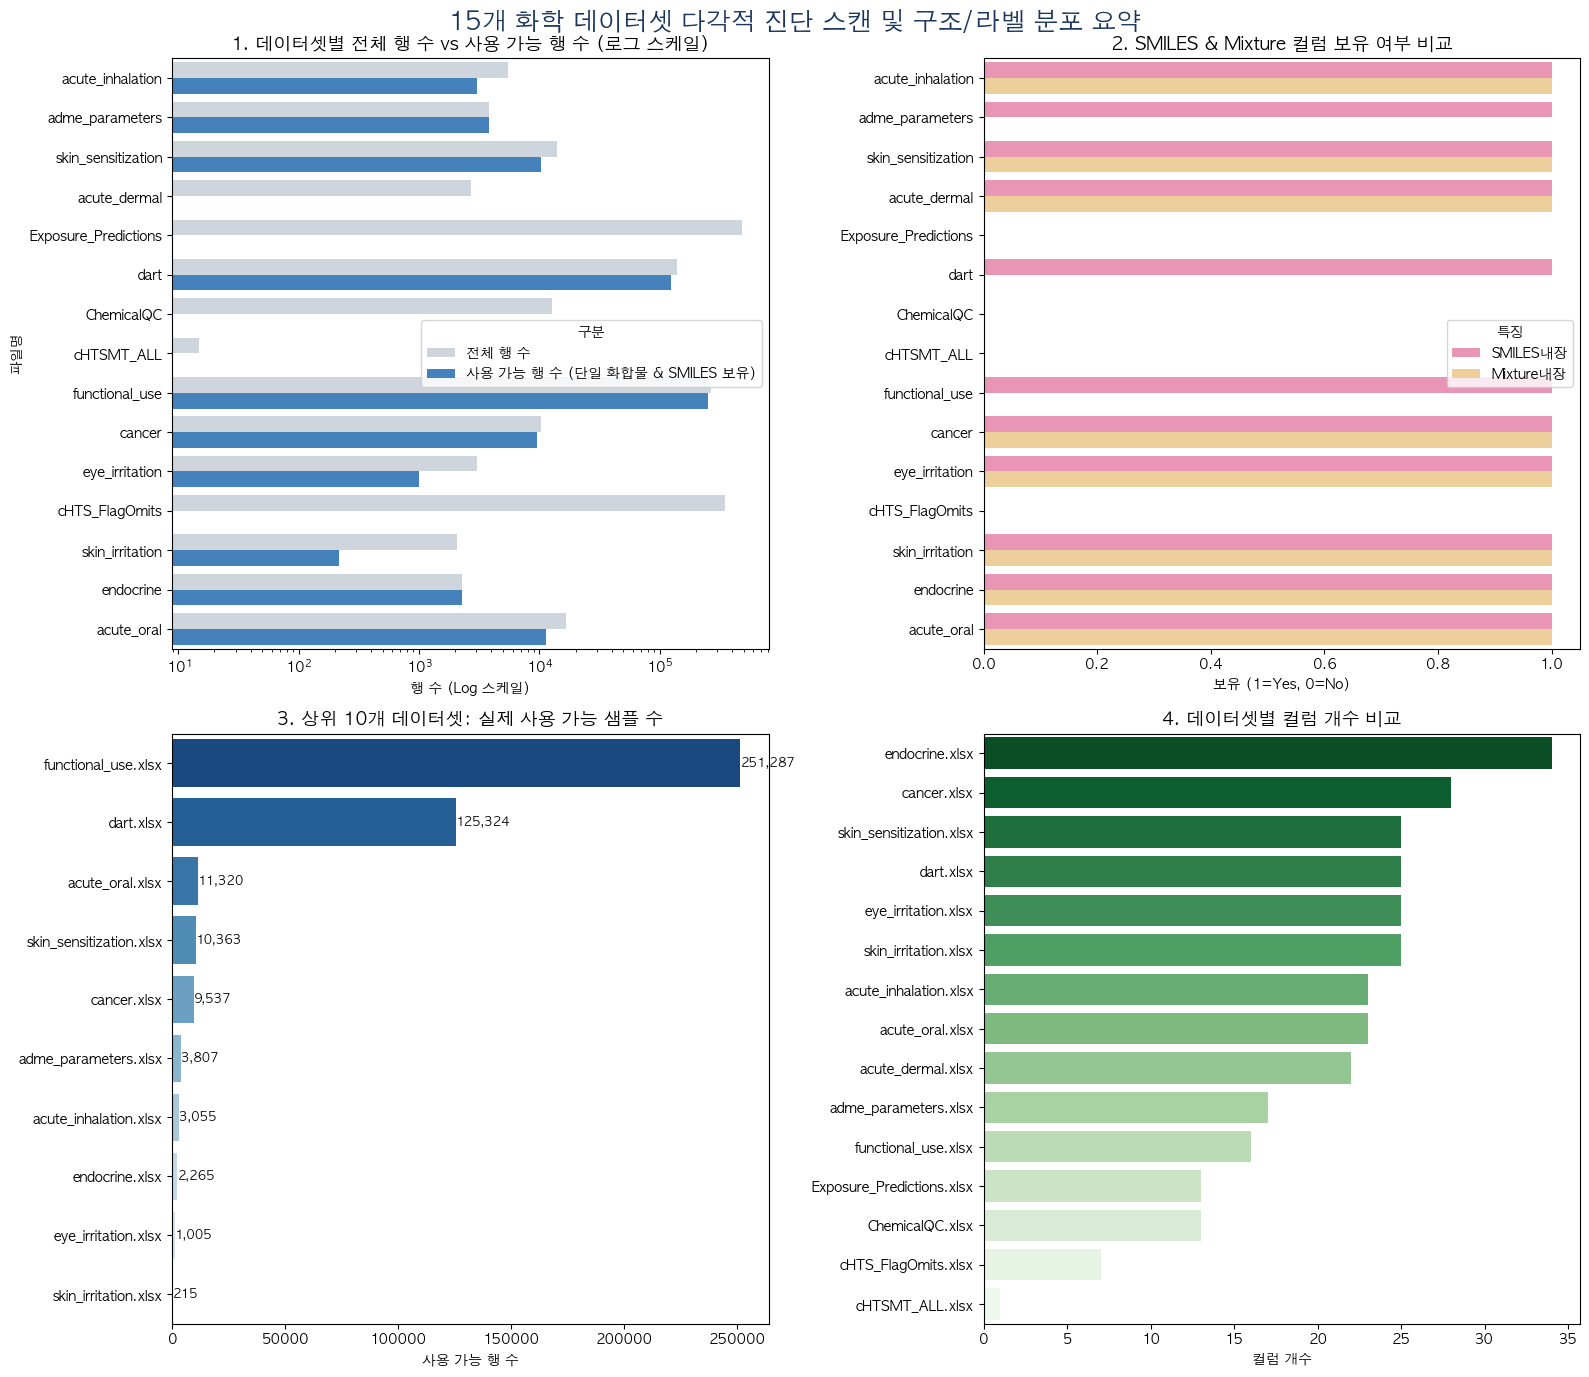

In [ ]:
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

if 'df_scan' not in globals():
    raise NameError('df_scan is not defined. Run the scan cell first.')

df_scan_plot = df_scan.copy()

# 열명이 '파일명'이 아닌 경우 처리
if 'SMILES내장' in df_scan_plot.columns and '파일명' in df_scan_plot.columns:
    titles = df_scan_plot['파일명'].str.replace('.xlsx', '')
    totals = df_scan_plot['전체행수'].tolist()
    usables = df_scan_plot['실제사용가능행수'].tolist()
    
    # 두 가지 정보를 하나의 DataFrame으로 결합하여 시각화
    df_plot = pd.DataFrame({
        '데이터셋': list(titles) * 2,
        '샘플 개수': totals + usables,
        '구분': ['전체 행 수'] * len(titles) + ['사용 가능 행 수 (단일 화합물 & SMILES 보유)'] * len(titles)
    })
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle('15개 화학 데이터셋 다각적 진단 스캔 및 구조/라벨 분포 요약', fontsize=18, fontweight='bold', color='#1a365d')
    
    # 1. 데이터셋별 전체 샘플 수 vs 실제 사용 가능 샘플 수 비교 (로그 스케일 멀티 바 차트)
    sns.barplot(x='샘플 개수', y='데이터셋', hue='구분', data=df_plot, ax=axes[0,0], palette=['#cbd5e0', '#3182ce'])
    axes[0,0].set_xscale('log')
    axes[0,0].set_title('1. 데이터셋별 전체 행 수 vs 사용 가능 행 수 (로그 스케일)', fontsize=13, fontweight='bold')
    axes[0,0].set_xlabel('행 수 (Log 스케일)')
    axes[0,0].set_ylabel('파일명')
    
    # 2. SMILES 내장 여부 및 Mixture 컬럼 보유 여부 비교
    df_features = df_scan_plot[['파일명', 'SMILES내장', 'Mixture내장']].copy()
    df_features['파일명'] = df_features['파일명'].str.replace('.xlsx', '')
    df_features_long = df_features.melt(id_vars='파일명', var_name='특징', value_name='보유')
    df_features_long['보유'] = df_features_long['보유'].astype(int)
    
    sns.barplot(x='보유', y='파일명', hue='특징', data=df_features_long, ax=axes[0,1], palette=['#f687b3', '#fbd38d'])
    axes[0,1].set_title('2. SMILES & Mixture 컬럼 보유 여부 비교', fontsize=13, fontweight='bold')
    axes[0,1].set_xlabel('보유 (1=Yes, 0=No)')
    axes[0,1].set_ylabel('')
    
    # 3. 실제 사용 가능한 샘플 수 비교
    df_usable = df_scan_plot.sort_values('실제사용가능행수', ascending=False).head(10)
    sns.barplot(x='실제사용가능행수', y='파일명', data=df_usable, ax=axes[1,0], palette='Blues_r')
    axes[1,0].set_title('3. 상위 10개 데이터셋: 실제 사용 가능 샘플 수', fontsize=13, fontweight='bold')
    axes[1,0].set_xlabel('사용 가능 행 수')
    axes[1,0].set_ylabel('')
    for i, v in enumerate(df_usable['실제사용가능행수']):
        axes[1,0].text(v + 100, i, f'{int(v):,}', va='center', fontsize=9, fontweight='bold')
    
    # 4. 데이터셋별 열(컬럼) 개수 비교
    sns.barplot(x='열수', y='파일명', data=df_scan_plot.sort_values('열수', ascending=False), ax=axes[1,1], palette='Greens_r')
    axes[1,1].set_title('4. 데이터셋별 컬럼 개수 비교', fontsize=13, fontweight='bold')
    axes[1,1].set_xlabel('컬럼 개수')
    axes[1,1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()

### 2. 진단 결과를 기반으로 한 데이터 선별 및 학습 배제 전략

#### ① 평가 기준

1. **적정 샘플 크기 (3,000 ~ 10,000행 내외):** 가용 표본이 1만 행을 초과하는 대형 데이터는 RDKit 분자 피처 추출 및 하이퍼파라미터 반복 튜닝 시 메모리 병목을 유발한다. 반대로 2,000행 미만의 소형 데이터는 화학적 공간(Chemical Space)을 충분히 대변하지 못해 과적합 위험이 크다. 따라서 연산 과부하가 없으면서도 표본이 가장 풍부한 구간을 최우선으로 한다.
2. **필수 식별자(SMILES, Mixture) 완비성:** 파일 내에 SMILES 코드와 단일 화합물 여부(`Mixture=Chemical`) 정보가 둘 다 내장되어 있어, 구조식 변환 에러나 혼합물 노이즈로 인한 데이터 유실 리스크가 적은 것을 우선한다.
3. **풍부한 특성(Feature) 열 구성:** 단순 타겟값 외에 실험 메타데이터를 다양하게 담고 있는 20개 이상의 열(Column)을 보유하여 피처 엔지니어링의 확장성이 높은 데이터셋을 선정한다.

#### ② 데이터셋 종합 대조 분석 및 상위 데이터셋

* **1: cancer.xlsx (발암성 데이터셋 - 최종 선정)**
  * **선정 사유:** 정제 후 9,537행의 가용 샘플을 확보하여, 1만 행 이하 연산 쾌적성을 유지하는 선에서 가장 풍부한 표본 수를 자랑한다. 필수 식별자인 SMILES와 Mixture 컬럼이 모두 내장되어 있으며, 28개의 열을 갖추고 있어 다각적 모델링 타겟으로 적합성을 보인다.

* **2: acute_inhalation.xlsx (급성 흡입 독성 데이터셋)**
  * **차순위 사유:** SMILES 및 Mixture 정보를 모두 갖추고 정제 후 3,055행의 깔끔한 규모를 가졌으나, `cancer.xlsx`(9,537행)에 비해 학습 표본 수가 1/3 수준에 불과해 더 넓은 화학적 공간을 학습하기에는 볼륨 면에서 다소 밀렸다.

* **3: adme_parameters.xlsx (ADME 파라미터 데이터셋)**
  * **차순위 사유:** 가용 샘플 3,807행으로 규모는 매우 적합하나, 단일 화합물 여부를 필터링할 `Mixture` 컬럼이 아예 존재하지 않는다(`False`). 이로 인해 데이터 내부에 복합 혼합물이 숨어있을 불확실성을 내포한다.

#### ③ 결론 및 최종 선정 의사결정

* 종합 대조 결과, `cancer.xlsx`가 [연산 효율을 해치지 않는 최대치의 표본 수 + 필수 구조식의 완벽한 내장 + 열 구성의 풍부함]을 충족하므로 최종 모델 타겟 데이터로 확정한다.
* 반면, 피처 추출에만 수십 시간이 걸리는 `functional_use`(25.1만 행)나 `dart`(12.5만 행) 등의 거대 데이터는 물리적 연산 한계로 배제하였으며, 정제 후 샘플 수가 215개에 불과한 `skin_irritation.xlsx`는 과적합 위험으로, 가용 행 수가 '0'으로 집계된 파일들(`Exposure_Predictions`, `acute_dermal` 등)은 대상에서 완전히 제외하였다.

## 1. 데이터 분포 파악 및 전처리
중복 화합물 체크, smiles 코드 정리
### 염 제거, 다단계 중복 제거 통합 파이프라인
- **PubChem Fallback API 내장:** SMILES가 공백이거나 누락된 경우 화합물명을 기반으로 온라인 DB에서 검색하여 Canonical SMILES를 자동으로 매핑한다.
- **다단계 데이터 정제 파이프라인:** 단일 화학물질 선별, RDKit SaltRemover 기반 Counter ion 염 제거 및 최장 유기골격 단일물질 추출, cxSMILES/고분자 필터링, 그리고 CASRN 및 분자 구조 기준의 2단계 양성 우선(Positive-priority) 중복 제거를 완료한다.

In [19]:
# =========================================================================
# 0,1. 데이터 로드 및 정성적 발암성 라벨 이진 매핑
# =========================================================================
file_path = os.path.join('dataset', 'cancer.xlsx')
df_raw = pd.read_excel(file_path, sheet_name='Data')
df_selec = df_raw[df_raw['Mixture'] == 'Chemical'].copy()

df_step0 = df_selec.copy()
print(f"  -> 0단계: 데이터 로드 완료. 샘플 수: {len(df_step0)}개")

# 정성적 라벨 정의
pos_labels = [
    'positive', 'clear evidence', 'some evidence', '1', '2a', '2b',
    'known to be a human carcinogen', 'reasonably anticipated to be a human carcinogen',
    'likely to be carcinogenic to humans', 'suggestive evidence of carcinogenic potential'
]
neg_labels = [
    'negative', 'no evidence', 'equivocal evidence',
    'not likely to be carcinogenic to humans', 'inadequate evidence to assess carcinogenic potential',
    'not classifiable as to its carcinogenicity to humans', '3', '4',
    'data are inadequate for an assessment of human carcinogenic potential'
]

df_selec['Response_clean'] = df_selec['Response'].astype(str).str.strip().str.lower()
df_selec['label'] = None
df_selec.loc[df_selec['Response_clean'].isin(pos_labels), 'label'] = 1
df_selec.loc[df_selec['Response_clean'].isin(neg_labels), 'label'] = 0

# 라벨 결측치 및 SMILES 결측치 1차 제거
df_step1 = df_selec.dropna(subset=['label']).copy()
print(f"  -> 1단계: 라벨 매핑 완료. 매핑된 유효 샘플 수: {len(df_step1)}개")


  -> 0단계: 데이터 로드 완료. 샘플 수: 10065개
  -> 1단계: 라벨 매핑 완료. 매핑된 유효 샘플 수: 5474개


In [20]:
def fetch_smiles_from_pubchem(chem_name):
    """
    SMILES가 없는 화합물명을 대비하여 이름 기반으로 PubChem DB에서 SMILES를 가져온다.
    """
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{chem_name}/property/CanonicalSMILES/JSON"
        response = requests.get(url, timeout=5)
        if response.status_code == 200:
            json_data = response.json()
            props = json_data['PropertyTable']['Properties'][0]
            smi_key = next((k for k in props.keys() if 'smiles' in k.lower()), None)
            if smi_key:
                return props[smi_key]
    except Exception:
        pass
    return None

In [21]:
# =========================================================================
# 2. SMILES 결측치에 대해 PubChem Fallback 조회 수행
# =========================================================================
smi_col = 'SMILES'
name_col = 'Chemical_Name'

# SMILES가 결측치인 행에 대해 온라인 PubChem REST API로 복원 시도
unmapped_smi = df_step1[df_step1[smi_col].isna() | (df_step1[smi_col].astype(str).str.strip() == "")]
print(f"  -> SMILES 누락 샘플 {len(unmapped_smi)}개에 대해 PubChem Fallback을 시작한다.")

for idx, row in unmapped_smi.iterrows():
    found_smi = fetch_smiles_from_pubchem(row[name_col])
    df_step1.at[idx, smi_col] = found_smi

df_step2 = df_step1.dropna(subset=[smi_col]).copy()
df_step2 = df_step2[df_step2[smi_col].astype(str).str.strip() != ""].copy()
print(f"  -> 2단계: SMILES 결측 복원 완료. 유효 샘플 수: {len(df_step2)}개")


  -> SMILES 누락 샘플 295개에 대해 PubChem Fallback을 시작한다.
  -> 2단계: SMILES 결측 복원 완료. 유효 샘플 수: 5273개


In [23]:
# =========================================================================
# 3. 비정형 cxSMILES 및 고분자 물질 배제
# =========================================================================
df_step3 = df_step2[
    (~df_step2[smi_col].astype(str).str.contains('|', regex=False)) &
    (~df_step2[smi_col].astype(str).str.contains('*', regex=False))
].copy()
print(f"  -> 3단계: 비정형 및 고분자 필터링 적용 완료. 유효 샘플 수: {len(df_step3)}개")


  -> 3단계: 비정형 및 고분자 필터링 적용 완료. 유효 샘플 수: 5193개


In [24]:
# =========================================================================
# 4. SaltRemover 염 제거 및 최장 유기골격 단일물질 추출
# =========================================================================
remover = SaltRemover()
standardized_smiles_list = []

for idx, row in df_step3.iterrows():
    smi = row[smi_col]
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        standardized_smiles_list.append(None)
        continue

    stripped_mol = remover.StripMol(mol)

    # 문자열 쪼개기(split) 대신 '분자 객체 상태' 그대로 조각을 냄
    frags = Chem.GetMolFrags(stripped_mol, asMols=True)

    if not frags:
        standardized_smiles_list.append(None)
        continue

    # 수소를 제외한 진짜 원자 개수(HeavyAtoms)가 가장 많은 메인 뼈대 선택
    active_mol = max(frags, key=lambda m: m.GetNumHeavyAtoms())

    # 탄소(C) 포함 여부 확인
    has_carbon = any(atom.GetSymbol() == 'C' for atom in active_mol.GetAtoms())

    if has_carbon:
        try:
            # 탄소(C)가 포함된 유기물질만 유지
            standardized_smiles_list.append(Chem.MolToSmiles(active_mol))
        except Exception:
            standardized_smiles_list.append(None)
    else:
        standardized_smiles_list.append(None)

df_step3['standardized_smi'] = standardized_smiles_list
df_step4 = df_step3.dropna(subset=['standardized_smi']).copy()

print(f"  -> 4단계: 염 제거 및 유기 성분 추출 완료. 샘플 수: {len(df_step4)}개")


  -> 4단계: 염 제거 및 유기 성분 추출 완료. 샘플 수: 4883개


In [35]:
# =========================================================================
# 5,6. CASRN 및 표준 구조 기반 양성 우선(Positive-priority) 중복 제거
# =========================================================================
# 1단계: CASRN 기준 중복 제거 (동일 CASRN에 대해 한 번이라도 발암성 양성(1)이면 양성으로 취급)
df_step5 = df_step4.groupby('CASRN').agg({
    'label': 'max',
    'standardized_smi': 'first',
    'Chemical_Name': 'first',
    'SMILES': 'first'
}).reset_index()
print(f"  -> 5단계: CASRN 기준 양성 우선 1차 중복 제거 완료. 샘플 수: {len(df_step5)}개")

# 2단계: standardized_smi 기준 중복 제거 (동일 표준 구조에 대해 발암성 양성 우선으로 최종 결정)
df_cleaned_final = df_step5.groupby('standardized_smi').agg({
    'label': 'max',
    'Chemical_Name': 'first',
    'CASRN': 'first',
    'SMILES': 'first'
}).reset_index()

print(f"  -> 6단계: 다단계 최종 중복 제거 완료. 최종 기계학습용 샘플 수: {len(df_cleaned_final)}개")
df_cleaned_final = df_cleaned_final.rename(columns={'SMILES': 'Original_SMILES'})
df_cleaned_final.to_csv('cancer_cleaned.csv', index=False)
print("전처리 완료 및 'cancer_cleaned.csv' 저장 성공!")


  -> 5단계: CASRN 기준 양성 우선 1차 중복 제거 완료. 샘플 수: 2324개
  -> 6단계: 다단계 최종 중복 제거 완료. 최종 기계학습용 샘플 수: 2269개
전처리 완료 및 'cancer_cleaned.csv' 저장 성공!


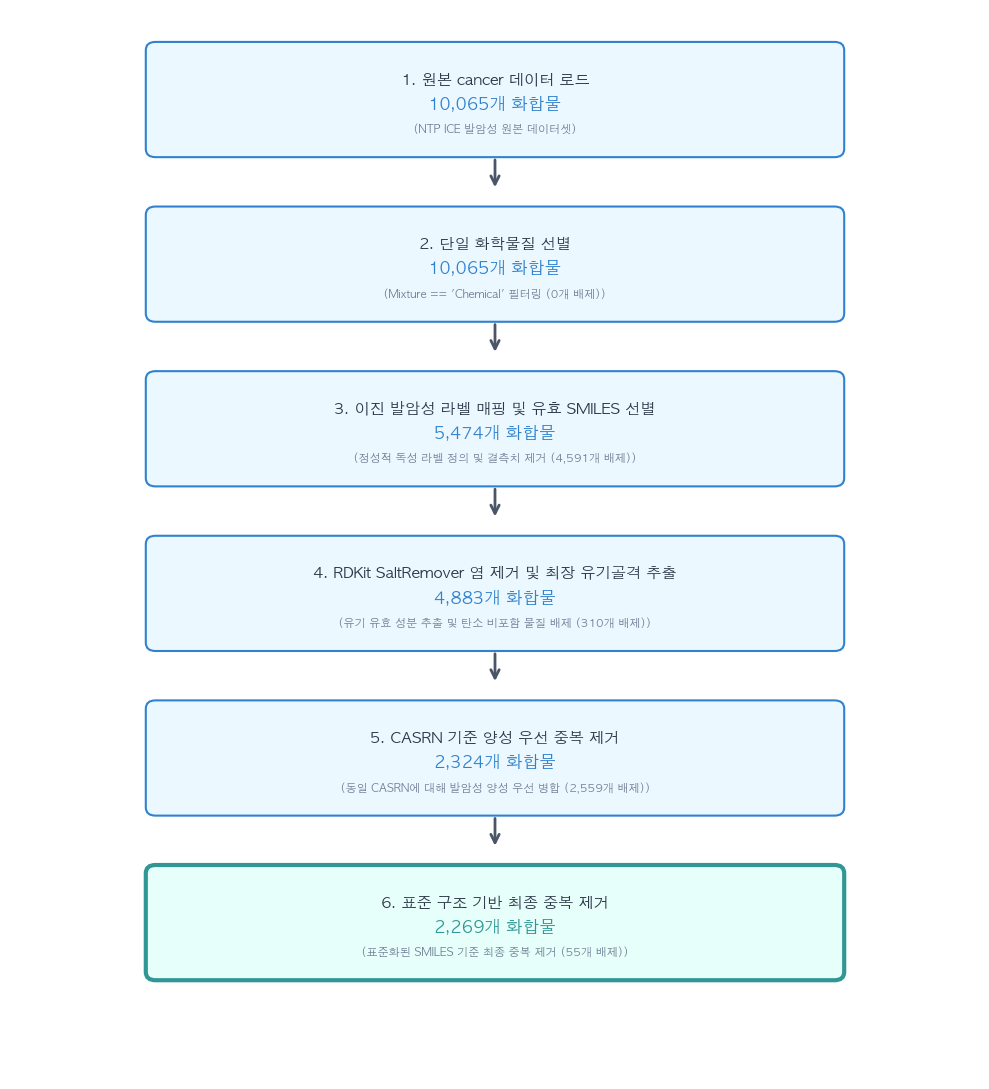

In [27]:
# 데이터 필터링 단계별 샘플 수 및 설명 설정 (위쪽 셀들의 실제 연산값 기반 동적 생성)
steps = [
    {"title": "1. 원본 cancer 데이터 로드", "count": f"{len(df_step0):,}개 화합물", "desc": "NTP ICE 발암성 원본 데이터셋"},
    {"title": "2. 단일 화학물질 선별", "count": f"{len(df_selec):,}개 화합물", "desc": f"Mixture == 'Chemical' 필터링 ({len(df_step0)-len(df_selec):,}개 배제)"},
    {"title": "3. 이진 발암성 라벨 매핑 및 유효 SMILES 선별", "count": f"{len(df_step1):,}개 화합물", "desc": f"정성적 독성 라벨 정의 및 결측치 제거 ({len(df_selec)-len(df_step1):,}개 배제)"},
    {"title": "4. RDKit SaltRemover 염 제거 및 최장 유기골격 추출", "count": f"{len(df_step4):,}개 화합물", "desc": f"유기 유효 성분 추출 및 탄소 비포함 물질 배제 ({len(df_step3)-len(df_step4):,}개 배제)"},
    {"title": "5. CASRN 기준 양성 우선 중복 제거", "count": f"{len(df_step5):,}개 화합물", "desc": f"동일 CASRN에 대해 발암성 양성 우선 병합 ({len(df_step4)-len(df_step5):,}개 배제)"},
    {"title": "6. 표준 구조 기반 최종 중복 제거", "count": f"{len(df_cleaned_final):,}개 화합물", "desc": f"표준화된 SMILES 기준 최종 중복 제거 ({len(df_step5)-len(df_cleaned_final):,}개 배제)"}
]

fig, ax = plt.subplots(figsize=(10, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(steps) * 2 + 1)
ax.axis('off')

for i, step in enumerate(steps):
    y_pos = len(steps) * 2 - i * 2
    
    box_color = '#ebf8ff' if i < len(steps)-1 else '#e6fffa'
    edge_color = '#3182ce' if i < len(steps)-1 else '#319795'
    linewidth = 1.5 if i < len(steps)-1 else 3
    
    rect = patches.FancyBboxPatch((1.5, y_pos - 0.7), 7, 1.2, boxstyle="round,pad=0.1",
                                 facecolor=box_color, edgecolor=edge_color, linewidth=linewidth)
    ax.add_patch(rect)
    
    ax.text(5, y_pos + 0.15, step['title'], ha='center', va='center', fontsize=11, fontweight='bold', color='#2d3748')
    ax.text(5, y_pos - 0.15, step['count'], ha='center', va='center', fontsize=12, fontweight='bold', color=edge_color)
    ax.text(5, y_pos - 0.45, f"({step['desc']})", ha='center', va='center', fontsize=8, color='#718096', style='italic')
    
    if i < len(steps) - 1:
        ax.annotate('', xy=(5, y_pos - 0.8), xytext=(5, y_pos - 1.2), 
                    arrowprops=dict(arrowstyle="<-", color='#4a5568', lw=2, mutation_scale=15))

plt.tight_layout()
plt.show()

### 전처리 과정

#### RDKit SaltRemover의 화학적 탈염
- 염(Salt) 형태를 띤 화합물(예: 카르복실산 나트륨염, 아민 염산염 등)은 주성분 외에 나트륨, 염소 등 무기 이온이 결합되어 있어 RDKit Descriptor 계산 시 원자 수나 분자량, 극성 표면적(TPSA) 등의 물리화학적 피처가 크게 왜곡된다.
- `SaltRemover`는 사전에 정의된 염 이온 목록을 기반으로 이를 분리하고, 가장 긴 탄소 결합 프래그먼트만을 추출함으로써 순수 활성 화학 성분(Active Ingredient)만을 정화하여 모델에 주입하도록 돕는다.

#### 다단계 중복 제거와 보수적 독성 판정 (Positive-priority)
- 동일한 화학 구조가 마우스, 랫드 등 다양한 개별 동물 실험 조건에 따라 복수의 행으로 존재할 수 있다.
- 이때 단순히 첫 번째 행을 취하거나 중복을 임의 기각하는 대신, 하나의 실험에서라도 발암성 양성(Carcinogenicity Positive)이 입증된 구조는 발암물질(Label = 1)로 판정하는 보수적 안전성 평가 방법론(Positive-priority)을 적용한다. 이는 인간 유해성 평가 시 보수적인 규제 한계치를 준수하려는 의사결정을 반영한다.

## 2. Descriptor 계산
### B. Feature(descriptor)의 다양성
## RDKit 디스크립터 및 6대 분자 지문 (Fingerprints) 다각화 통합 계산 모듈
- RDKit의 물리화학적 2D 디스크립터 계산 및 6가지 고차원 분자 지문(Morgan, Path-based, MACCS, Atom Pairs, Topological Torsion, Pattern) 계산 모듈을 설계한다.
- CPU 병렬 연산 라이브러리인 `joblib`을 연동하여 코어 전체를 동원함으로써 특징 연산 처리를 가속화한다.


In [34]:
# =========================================================================
# RDKit 디스크립터 및 6대 핑거프린트 개별 분자 추출 함수 설계
# =========================================================================
df_clean = pd.read_csv("cancer_cleaned.csv")
print(f"정제된 화학 데이터 로드 완료. 분자 수: {len(df_clean)}개")

# RDKit 고유의 비트 벡터(DataStructs) 객체를 NumPy 1차원 배열로 고속 변환하는 함수
def fp_to_numpy(fp):
    arr = np.zeros((0,), dtype=int)
    AllChem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# 단일 SMILES 문자열을 입력받아 1개의 디스크립터 딕셔너리와 6종의 핑거프린트를 추출하는 함수
def process_single_molecule(smi):
    try:
        # 1. SMILES 문자열을 RDKit 분자(Mol) 객체로 변환
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None  # 구조 변환에 실패한 SMILES는 연산 중단

        # 2. 1D/2D 물리화학적 분자 디스크립터 일괄 연산 (분자량, LogP, TPSA 등)
        desc_val = Descriptors.CalcMolDescriptors(mol)

        # 3. 핑거프린트 생성을 위한 RDKit 제너레이터 객체 초기화
        morgan_gen = AllChem.GetMorganGenerator(
            radius=2
        )  # Morgan (ECFP4 상당, 원자 반경 2 이내의 원형 부분구조)
        rdkit_gen = AllChem.GetRDKitFPGenerator()  # RDKit (DayLight 방식의 선형/분기형 경로 기반)
        atompair_gen = AllChem.GetAtomPairGenerator()  # Atom Pair (두 원자 사이의 거리와 위상학적 환경 쌍)
        torsion_gen = AllChem.GetTopologicalTorsionGenerator()  # Topological Torsion (4개의 연속된 원자 결합 경로 비틀림)

        # 4. 6대 핑거프린트 추출 및 NumPy 배열 변환
        fp_morgan = fp_to_numpy(morgan_gen.GetFingerprint(mol))
        fp_rdkit = fp_to_numpy(rdkit_gen.GetFingerprint(mol))
        fp_maccs = fp_to_numpy(
            MACCSkeys.GenMACCSKeys(mol)
        )  # MACCS Keys (166개의 사전 정의된 핵심 작용기 유무 O/X 키)
        fp_ap = fp_to_numpy(atompair_gen.GetFingerprint(mol))
        fp_tt = fp_to_numpy(torsion_gen.GetFingerprint(mol))
        fp_pat = fp_to_numpy(
            Chem.PatternFingerprint(mol)
        )  # Pattern (하위 구조 검색 및 스크리닝에 특화된 패턴)

        # 5. 추출된 총 7개의 피처 그룹을 하나의 튜플로 묶어서 반환
        return (desc_val, fp_morgan, fp_rdkit, fp_maccs, fp_ap, fp_tt, fp_pat)

    except Exception:
        return None

정제된 화학 데이터 로드 완료. 분자 수: 2269개


In [33]:
# =========================================================================
# Joblib Parallel을 활용한 멀티프로세스 피처 고속 대량 추출
# =========================================================================
smiles_list = df_clean['standardized_smi'].tolist()

print("Joblib 멀티코어 병렬 연산(n_jobs=-1)을 사용하여 피처 추출")
raw_features = Parallel(n_jobs=-1, verbose=5)(
    delayed(process_single_molecule)(smi) for smi in smiles_list
)
print("피처 연산 완료.")


Joblib 멀티코어 병렬 연산(n_jobs=-1)을 사용하여 피처 추출


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


피처 연산 완료.


In [36]:
# =========================================================================
# 피처 정렬, 접두사(Prefix) 라벨링 및 final_dataset_descriptors.csv 저장
# =========================================================================
valid_indices = []
desc_rows = []
fp_morgan_rows = []
fp_rdkit_rows = []
fp_maccs_rows = []
fp_ap_rows = []
fp_tt_rows = []
fp_pat_rows = []

for idx, feat in enumerate(raw_features):
    if feat is not None:
        valid_indices.append(idx)
        desc_rows.append(feat[0])
        fp_morgan_rows.append(feat[1])
        fp_rdkit_rows.append(feat[2])
        fp_maccs_rows.append(feat[3])
        fp_ap_rows.append(feat[4])
        fp_tt_rows.append(feat[5])
        fp_pat_rows.append(feat[6])

df_valid = df_clean.iloc[valid_indices].copy()

# 1. 2D Descriptor DataFrame
df_desc = pd.DataFrame(desc_rows)

# 2. 6대 분자 지문 DataFrame 구축 및 접두사(Prefix) 결합
df_morgan = pd.DataFrame(fp_morgan_rows).add_prefix('Morgan_')
df_rdkit = pd.DataFrame(fp_rdkit_rows).add_prefix('RDKit_')
df_maccs = pd.DataFrame(fp_maccs_rows).add_prefix('MACCS_')
df_ap = pd.DataFrame(fp_ap_rows).add_prefix('AtomPair_')
df_tt = pd.DataFrame(fp_tt_rows).add_prefix('Torsion_')
df_pat = pd.DataFrame(fp_pat_rows).add_prefix('Pattern_')

# 가로 병합 (Horizontal Concatenation)
df_features = pd.concat([
    df_desc.reset_index(drop=True),
    df_morgan.reset_index(drop=True),
    df_rdkit.reset_index(drop=True),
    df_maccs.reset_index(drop=True),
    df_ap.reset_index(drop=True),
    df_tt.reset_index(drop=True),
    df_pat.reset_index(drop=True)
        ], axis=1)

# 메타 정보와 결합
df_metadata = df_valid[['Chemical_Name', 'standardized_smi', 'label']].reset_index(drop=True)
df_metadata = df_metadata.rename(columns={'standardized_smi': 'SMILES'})
df_final_dataset = pd.concat([df_metadata, df_features], axis=1)

# 최종 파일 저장
df_final_dataset.to_csv('final_dataset_descriptors.csv', index=False)
print(f"피처 다각화 병렬 결합 완료! 파일 크기: {df_final_dataset.shape}")


피처 다각화 병렬 결합 완료! 파일 크기: (2269, 10627)


### 데이터셋 로딩 및 3분할 전처리 (StandardScaler & Train/Val/Test Split)

* 생성된 디스크립터 및 분자 지문 특징 행렬 `final_dataset_descriptors.csv` 파일을 로드한다.
* 결측치(NaN)가 포함된 피처 컬럼을 기각하고, 분산이 매우 낮은(표준편차 0.01 미만) 상수 성격의 컬럼을 차원 축소 차원에서 필터링한다.
* 데이터의 원본 클래스 불균형 비율을 유지하는 층화추출(Stratified) 방식을 적용하여, 데이터를 [모델 학습용(Train, 80%) / 하이퍼파라미터 튜닝용(Validation, 10%) / 최종 성능 검증용(Test, 10%)]의 8:1:1 구조로 정밀 분할한다.
* 독립 변수의 스케일 통일을 위해 `StandardScaler`를 적용한다. 이때 검증 세트로의 정보 누수(Data Leakage)를 차단하기 위해 스케일러는 오직 Train 세트에만 학습(`fit`)시키며, 변환 완료된 3분할 세트를 `train_test_data.joblib` 파일로 패키징하여 일괄 저장한다.

In [44]:
# =========================================================================
# 데이터셋 로드, NaN 및 저분산 피처 제거
# =========================================================================

data = pd.read_csv('final_dataset_descriptors.csv')
print(f"최종 피처 데이터셋 로드 완료: {data.shape}")

y = data['label'].astype(int)
X = data.drop(columns=['Chemical_Name', 'SMILES', 'label'])

# 1단계: NaN 컬럼 제거
X = X.dropna(axis=1)
print(f"  -> NaN 제거 후 피처 차원: {X.shape}")

# 2단계: 저분산 컬럼 필터링 (std >= 0.01)
low_variance_mask = X.std() >= 0.01
X = X.loc[:, low_variance_mask]
print(f"  -> 저분산 제거 후 최종 피처 차원: {X.shape}")

# =========================================================================
# Stratified Train / Validation / Test Split (8:1:1) 및 StandardScaler 적용
# =========================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd

# 1차 분할: 전체 데이터를 [Train 80% vs (Val + Test) 20%] 로 쪼개기
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2차 분할: 남은 20%를 정확히 반반(0.5) 나누어 [Validation 10% vs Test 10%] 로 쪼개기
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# 스케일러 학습은 반드시 'Train 세트'에만 수행! (Val, Test에 fit하면 데이터 누수 발생)
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw), columns=X_train_raw.columns
)
X_val = pd.DataFrame(scaler.transform(X_val_raw), columns=X_val_raw.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)

print(f"■ 훈련 데이터(Train)   : {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)")
print(f"■ 검증 데이터(Validation): {X_val.shape} ({len(X_val)/len(X)*100:.1f}%)")
print(f"■ 테스트 데이터(Test)    : {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)")

print(
    f"\n양성 클래스 비율 ➔ Train: {y_train.mean():.3f} | Val: {y_val.mean():.3f} | Test: {y_test.mean():.3f}"
)

# 모델링 단계에 인계하기 위한 3분할 데이터 패키징
save_pkg = {
    "X_train": X_train,
    "X_val": X_val,
    "X_test": X_test,
    "y_train": y_train.values,
    "y_val": y_val.values,
    "y_test": y_test.values,
    "features": X.columns.tolist(),
    "scaler": scaler,
}

joblib.dump(save_pkg, "train_test_data.joblib")
print(
    "\n전처리 완료된 3분할 데이터셋(Train/Val/Test) 및 스케일러가 'train_test_data.joblib'으로 저장되었다."
)

최종 피처 데이터셋 로드 완료: (2269, 10627)
  -> NaN 제거 후 피처 차원: (2269, 10612)
  -> 저분산 제거 후 최종 피처 차원: (2269, 9909)
■ 훈련 데이터(Train)   : (1815, 9909) (80.0%)
■ 검증 데이터(Validation): (227, 9909) (10.0%)
■ 테스트 데이터(Test)    : (227, 9909) (10.0%)

양성 클래스 비율 ➔ Train: 0.410 | Val: 0.410 | Test: 0.410

전처리 완료된 3분할 데이터셋(Train/Val/Test) 및 스케일러가 'train_test_data.joblib'으로 저장되었다.


### 분자 물리화학 공간 다양성 분석 및 화학 도메인 영역 대변성 검증 (Train/Val/Test 3D 공간 검증)

* 전체 발암성 데이터셋(`cancer`) 내 화합물들의 분자량(Molecular Weight, MolWt) 및 지질친화도(MolLogP) 분포를 Scatter Plot으로 시각화하여 모델링 대상 데이터셋의 화학 공간(Chemical Space) 다양성을 진단한다.
* 분할된 **훈련용(Train), 중간 튜닝용(Validation), 최종 평가용(Test)** 데이터셋이 화학 도메인 상에서 편향 없이 균일하게 삼중 중첩(Triple Overlay) 및 대변(Coverage)되고 있는지 시각적으로 입증한다.
* 이를 통해 모델 학습 과정과 하이퍼파라미터 최적화, 그리고 최종 외삽 성능 평가가 모두 동일한 화학적 영역(Domain) 내에서 안정적으로 수행됨을 보증한다.

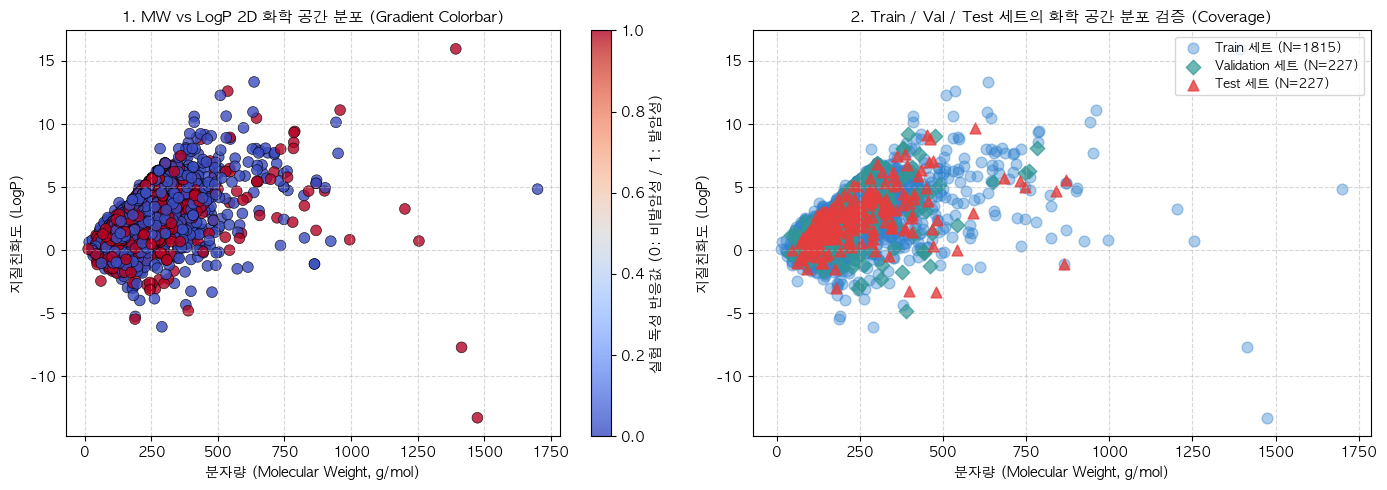

In [45]:
# =========================================================================
# 분자 물리화학 공간 다양성 분석 (MW vs LogP 분포 및 3분할 데이터셋 대변성 연계)
# =========================================================================
# 1. 화학 다양성 공간 MW vs LogP 2D Scatter Plot (라벨값 color gradient 및 3분할 검증)
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 5))

# (1) 전체 데이터의 MW vs LogP 화학 공간 분포 시각화 (Gradient Colorbar)
plt.subplot(1, 2, 1)
scatter = plt.scatter(
    X["MolWt"],
    X["MolLogP"],
    c=y,
    cmap="coolwarm",
    s=60,
    alpha=0.8,
    edgecolors="black",
    linewidth=0.5,
)
cbar = plt.colorbar(scatter)
cbar.set_label(
    "실험 독성 반응값 (0: 비발암성 / 1: 발암성)", fontsize=10, fontweight="bold"
)
plt.title(
    "1. MW vs LogP 2D 화학 공간 분포 (Gradient Colorbar)",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("분자량 (Molecular Weight, g/mol)", fontsize=10)
plt.ylabel("지질친화도 (LogP)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

# (2) Train vs Val vs Test 세트의 화학 공간 삼중 중첩 대변성 (Chemical Space Coverage) 플롯
plt.subplot(1, 2, 2)
# 1. Train 세트 플롯 (기반 배경 구름 역할 - 파란색 원)
plt.scatter(
    X_train_raw["MolWt"],
    X_train_raw["MolLogP"],
    color="#3182ce",
    label=f"Train 세트 (N={len(X_train_raw)})",
    s=60,
    alpha=0.4,
    marker="o",
)

# 2. Validation 세트 플롯 (중간 점검용 - 초록색 다이아몬드)
plt.scatter(
    X_val_raw["MolWt"],
    X_val_raw["MolLogP"],
    color="#319795",
    label=f"Validation 세트 (N={len(X_val_raw)})",
    s=55,
    alpha=0.7,
    marker="D",
)

# 3. Test 세트 플롯 (최종 검증용 - 빨간색 삼각형)
plt.scatter(
    X_test_raw["MolWt"],
    X_test_raw["MolLogP"],
    color="#e53e3e",
    label=f"Test 세트 (N={len(X_test_raw)})",
    s=60,
    alpha=0.8,
    marker="^",
)

plt.title(
    "2. Train / Val / Test 세트의 화학 공간 분포 검증 (Coverage)",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("분자량 (Molecular Weight, g/mol)", fontsize=10)
plt.ylabel("지질친화도 (LogP)", fontsize=10)
plt.legend(fontsize=9, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

학습용(Train), 중간 점검용(Validation), 최종 평가용(Test) 데이터셋이 분자량(MW)과 지질친화도(LogP)를 기준으로 정의된 화학 공간 상에 치우침 없이 골고루 잘 분산되어 중첩(Coverage)되어있다.